In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/archive (2).zip"
extract_path = "/content/drive/MyDrive/archive_4"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Unzipped successfully!")


✅ Unzipped successfully!


In [5]:
print(os.listdir(extract_path))


['Testing', 'Training']


In [7]:
base_path = "/content/drive/MyDrive/archive_4"

train_path = os.path.join(base_path, "Training")
test_path  = os.path.join(base_path, "Testing")

print(os.listdir(train_path))
print(os.listdir(test_path))


['glioma', 'meningioma', 'notumor', 'pituitary']
['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
import os

for split in ["Training", "Testing"]:
    old_path = f"/content/drive/MyDrive/archive_4/{split}/notumor"
    new_path = f"/content/drive/MyDrive/archive_4/{split}/no_tumor"

    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print("✅ Folder renamed successfully")


✅ Folder renamed successfully


In [9]:
!pip install timm imagehash


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.6 MB/s eta 0:00:00


In [10]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from PIL import Image
import timm


In [11]:
BASE_PATH = "/content/drive/MyDrive/archive_4"

TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")


In [12]:
def clean_dataset(folder):
    MIN_SIZE = 64
    removed = 0

    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue

        for img in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img)
            try:
                with Image.open(img_path) as im:
                    im.verify()

                with Image.open(img_path) as im:
                    w, h = im.size
                    if w < MIN_SIZE or h < MIN_SIZE:
                        os.remove(img_path)
                        removed += 1
            except:
                if os.path.exists(img_path):
                    os.remove(img_path)
                    removed += 1

    print(f"✅ Cleaned {folder} | Removed {removed} images")


In [13]:
clean_dataset(TRAIN_PATH)
clean_dataset(TEST_PATH)


✅ Cleaned /content/drive/MyDrive/archive_4/Training | Removed 0 images
✅ Cleaned /content/drive/MyDrive/archive_4/Testing | Removed 0 images


In [14]:
IMAGE_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [15]:
from torchvision import datasets

train_data = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_data  = datasets.ImageFolder(TEST_PATH, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

class_names = train_data.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Number of classes: 4


In [17]:
import torch

device = torch.device("cuda")
print("🚀 Using GPU:", torch.cuda.get_device_name(0))


🚀 Using GPU: Tesla T4


In [20]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=num_classes
)


In [21]:
model = model.to(device)


In [22]:
model = model.to(device)
optimizer = AdamW(model.parameters())  # ✅


NameError: name 'AdamW' is not defined

In [23]:
from torch.optim import AdamW


In [33]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4   # ⭐ REGULARIZATION
)


In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)


In [26]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {running_loss:.4f} | Train Acc: {acc:.2f}%")


Epoch [1/10] | Loss: 90.8670 | Train Acc: 90.67%
Epoch [2/10] | Loss: 34.1074 | Train Acc: 96.94%
Epoch [3/10] | Loss: 21.2569 | Train Acc: 98.07%
Epoch [4/10] | Loss: 21.5502 | Train Acc: 98.13%
Epoch [5/10] | Loss: 19.0129 | Train Acc: 98.18%
Epoch [6/10] | Loss: 12.3088 | Train Acc: 98.90%
Epoch [7/10] | Loss: 11.6368 | Train Acc: 98.88%
Epoch [8/10] | Loss: 16.7933 | Train Acc: 98.49%
Epoch [9/10] | Loss: 10.5655 | Train Acc: 99.18%
Epoch [10/10] | Loss: 10.5229 | Train Acc: 99.18%


In [34]:
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=num_classes,
    drop_rate=0.3,        # classifier dropout
    drop_path_rate=0.2    # stochastic depth (VERY effective)
)
model = model.to(device)


In [39]:
import os

BASE_PATH = "/content/drive/MyDrive/archive_3"

TRAIN_PATH = os.path.join(BASE_PATH, "Training")
VAL_PATH   = os.path.join(BASE_PATH, "Testing")   # used as validation

print("Train path:", TRAIN_PATH)
print("Val path:", VAL_PATH)


Train path: /content/drive/MyDrive/archive_3/Training
Val path: /content/drive/MyDrive/archive_3/Testing


In [40]:
from torchvision import datasets
from torch.utils.data import DataLoader

val_data = datasets.ImageFolder(VAL_PATH, transform=val_transform)

val_loader = DataLoader(
    val_data,
    batch_size=16,
    shuffle=False
)

print("Validation samples:", len(val_data))


NameError: name 'val_transform' is not defined

In [35]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [36]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)


In [37]:
EPOCHS = 10
patience = 3
trigger = 0
best_val_loss = float("inf")

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ================= VALIDATION =================
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    # ================= LOG =================
    print(f"""
Epoch [{epoch+1}/{EPOCHS}]
Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%
Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%
""")

    # ================= SAVE BEST =================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger = 0
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/checkpoints/best_swin_model.pth")
        print("🔥 Best model saved")
    else:
        trigger += 1
        if trigger >= patience:
            print("⏹️ Early stopping triggered")
            break


NameError: name 'val_loader' is not defined

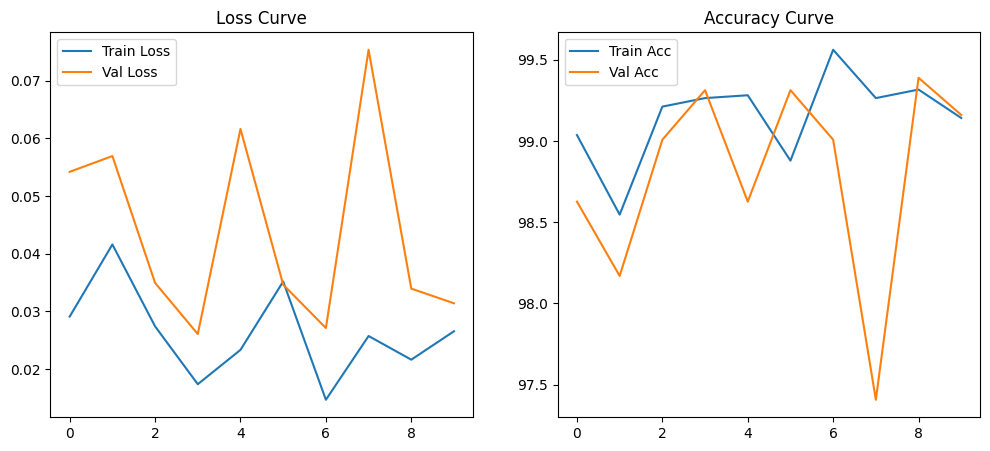

In [32]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    correct, total, running_loss = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100 * correct / total)

    model.eval()
    correct, total, running_loss = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_losses.append(running_loss / len(test_loader))
    val_accs.append(100 * correct / total)

# 📈 PLOTS
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


In [43]:
from PIL import Image
import os

def remove_corrupt_images(folder_path):
    removed = 0

    for cls in os.listdir(folder_path):
        cls_path = os.path.join(folder_path, cls)
        if not os.path.isdir(cls_path):
            continue

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()   # checks corruption
            except:
                os.remove(img_path)
                removed += 1
                print("❌ Removed:", img_path)

    print(f"✅ Finished cleaning {folder_path}")
    print(f"🗑️ Total removed: {removed}")


In [44]:
remove_corrupt_images(TRAIN_PATH)
remove_corrupt_images(VAL_PATH)


✅ Finished cleaning /content/drive/MyDrive/archive_3/Training
🗑️ Total removed: 0
❌ Removed: /content/drive/MyDrive/archive_3/Testing/glioma/Te-gl_0288.jpg
✅ Finished cleaning /content/drive/MyDrive/archive_3/Testing
🗑️ Total removed: 1


In [46]:
# =========================
# 1. IMPORTS
# =========================
import os
import torch
import torch.nn as nn
from torch.optim import AdamW
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import timm

# =========================
# 2. DEVICE (GPU)
# =========================
assert torch.cuda.is_available(), "GPU not available"
device = torch.device("cuda")
print("Using GPU:", torch.cuda.get_device_name(0))

# =========================
# 3. DATASET PATHS
# =========================
BASE_PATH = "/content/drive/MyDrive/archive_3"
TRAIN_PATH = os.path.join(BASE_PATH, "Training")
VAL_PATH   = os.path.join(BASE_PATH, "Testing")

# =========================
# 4. DATA TRANSFORMS
# =========================
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =========================
# 5. LOAD DATA
# =========================
train_data = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_data   = datasets.ImageFolder(VAL_PATH, transform=val_transform)

train_loader = DataLoader(
    train_data, batch_size=16, shuffle=True,
    num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    val_data, batch_size=16, shuffle=False,
    num_workers=2, pin_memory=True
)

class_names = train_data.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Train samples:", len(train_data))
print("Val samples:", len(val_data))

# =========================
# 6. MODEL (SWIN + REGULARIZATION)
# =========================
model = timm.create_model(
    "swin_tiny_patch4_window7_224",
    pretrained=True,
    num_classes=num_classes,
    drop_rate=0.3,
    drop_path_rate=0.2
)

model = model.to(device)

# =========================
# 7. LOSS & OPTIMIZER
# =========================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

# =========================
# 8. TRAINING + VALIDATION
# =========================
EPOCHS = 10
patience = 3
trigger = 0
best_val_loss = float("inf")

os.makedirs("/content/drive/MyDrive/checkpoints", exist_ok=True)

for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total

    # ---- VALIDATION ----
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total

    print(f"""
Epoch [{epoch+1}/{EPOCHS}]
Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%
Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%
""")

    # ---- EARLY STOPPING + SAVE BEST ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger = 0
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/checkpoints/best_swin_model.pth")
        print("🔥 Best model saved")
    else:
        trigger += 1
        if trigger >= patience:
            print("⏹️ Early stopping triggered")
            break

# =========================
# 9. LOAD BEST MODEL
# =========================
model.load_state_dict(
    torch.load("/content/drive/MyDrive/checkpoints/best_swin_model.pth")
)
model.eval()

print("✅ Training & validation complete")


Using GPU: Tesla T4
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train samples: 5712
Val samples: 1310

Epoch [1/10]
Train Loss: 0.9736 | Train Acc: 64.95%
Val   Loss: 0.8075 | Val   Acc: 79.54%

🔥 Best model saved

Epoch [2/10]
Train Loss: 0.5781 | Train Acc: 89.57%
Val   Loss: 0.5108 | Val   Acc: 92.37%

🔥 Best model saved

Epoch [3/10]
Train Loss: 0.5325 | Train Acc: 91.33%
Val   Loss: 0.4881 | Val   Acc: 93.51%

🔥 Best model saved

Epoch [4/10]
Train Loss: 0.5050 | Train Acc: 92.87%
Val   Loss: 0.5355 | Val   Acc: 91.15%


Epoch [5/10]
Train Loss: 0.4965 | Train Acc: 93.15%
Val   Loss: 0.4359 | Val   Acc: 95.65%

🔥 Best model saved

Epoch [6/10]
Train Loss: 0.4850 | Train Acc: 93.80%
Val   Loss: 0.4282 | Val   Acc: 96.49%

🔥 Best model saved

Epoch [7/10]
Train Loss: 0.4710 | Train Acc: 94.68%
Val   Loss: 0.4534 | Val   Acc: 95.88%


Epoch [8/10]
Train Loss: 0.4614 | Train Acc: 94.68%
Val   Loss: 0.4257 | Val   Acc: 96.56%

🔥 Best model saved

Epoch [9/10]
Train Loss:

In [47]:
import torch
import numpy as np

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:   # Testing set
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)


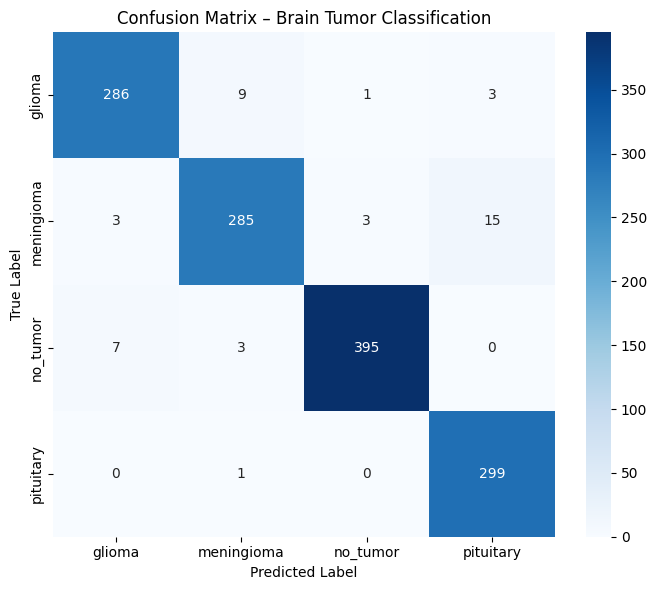

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Brain Tumor Classification")
plt.tight_layout()
plt.show()


In [49]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    r2_score,
    classification_report
)

# -------------------------------
# Collect predictions
# -------------------------------
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:   # testing set
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total test samples:", len(y_true))

# -------------------------------
# Metrics
# -------------------------------

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true, y_pred, average="weighted", zero_division=0
)

recall = recall_score(
    y_true, y_pred, average="weighted", zero_division=0
)

f1 = f1_score(
    y_true, y_pred, average="weighted", zero_division=0
)

mse = mean_squared_error(y_true, y_pred)

r2 = r2_score(y_true, y_pred)

# -------------------------------
# Print results
# -------------------------------
print("\n📊 TEST METRICS")
print(f"✅ Accuracy : {accuracy*100:.2f}%")
print(f"🎯 Precision: {precision:.4f}")
print(f"🔁 Recall   : {recall:.4f}")
print(f"🏆 F1-score : {f1:.4f}")
print(f"📉 MSE      : {mse:.4f}")
print(f"📈 R² Score : {r2:.4f}")

# -------------------------------
# Detailed per-class report
# -------------------------------
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))


Total test samples: 1310

📊 TEST METRICS
✅ Accuracy : 96.56%
🎯 Precision: 0.9660
🔁 Recall   : 0.9656
🏆 F1-score : 0.9656
📉 MSE      : 0.1076
📈 R² Score : 0.9075

📋 Classification Report:
              precision    recall  f1-score   support

      glioma       0.97      0.96      0.96       299
  meningioma       0.96      0.93      0.94       306
    no_tumor       0.99      0.98      0.98       405
   pituitary       0.94      1.00      0.97       300

    accuracy                           0.97      1310
   macro avg       0.96      0.96      0.96      1310
weighted avg       0.97      0.97      0.97      1310



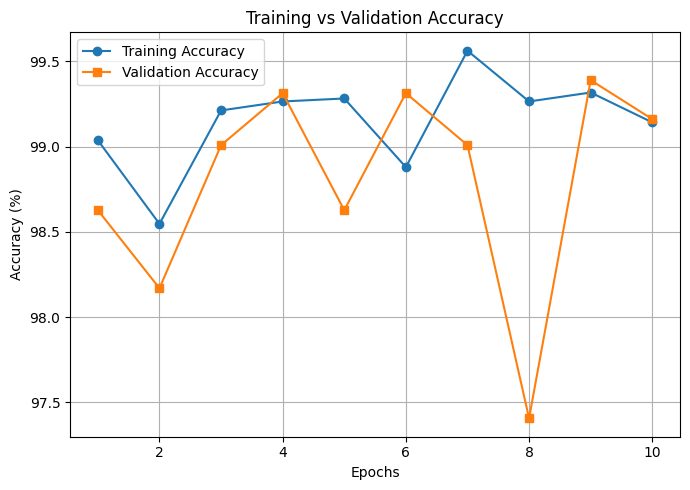

In [50]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_accs) + 1)

plt.figure(figsize=(7,5))
plt.plot(epochs, train_accs, marker='o', label='Training Accuracy')
plt.plot(epochs, val_accs, marker='s', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
